# Diamond Pricing Analytics

Diagnostic analytics on a 53,940 record diamond sales dataset to identify what actually drives price and where naive, unadjusted comparisons mislead.

**Dataset:** the seaborn `diamonds` sample dataset (carat, cut, color, clarity, dimensions, and price for 53,940 diamonds), loaded directly from the official [seaborn-data](https://github.com/mwaskom/seaborn-data) repository.

**Objective:** move past a single "average price by category" view and identify the confound that makes it misleading, then find the driver that actually explains price.

## 1. Setup and Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = sns.load_dataset("diamonds")
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Shape: 53,940 rows, 10 columns


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 2. Data Cleaning

In [2]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape[0]:,} rows")

df["price_per_carat"] = df["price"] / df["carat"]

Missing values: 0
Duplicate rows: 146
Shape after dropping duplicates: 53,794 rows


## 3. Price Distribution

count    53794.00
mean      3933.07
std       3988.11
min        326.00
25%        951.00
50%       2401.00
75%       5326.75
max      18823.00
Name: price, dtype: float64


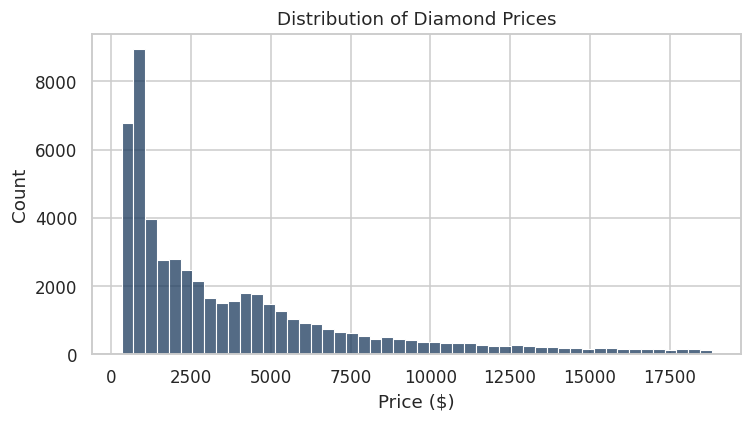

In [3]:
print(df["price"].describe().round(2))

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df["price"], bins=50, color="#1B3A5C", ax=ax)
ax.set_title("Distribution of Diamond Prices")
ax.set_xlabel("Price ($)")
plt.tight_layout()
plt.savefig("charts/01_price_distribution.png")
plt.show()

**Finding:** prices range from \$326 to \$18,823, with a median of \$2,401 and a long right tail. The distribution is heavily skewed, most diamonds are inexpensive and a small share are very high value.

## 4. Carat as the Primary Price Driver

Correlation between carat and price: 0.922


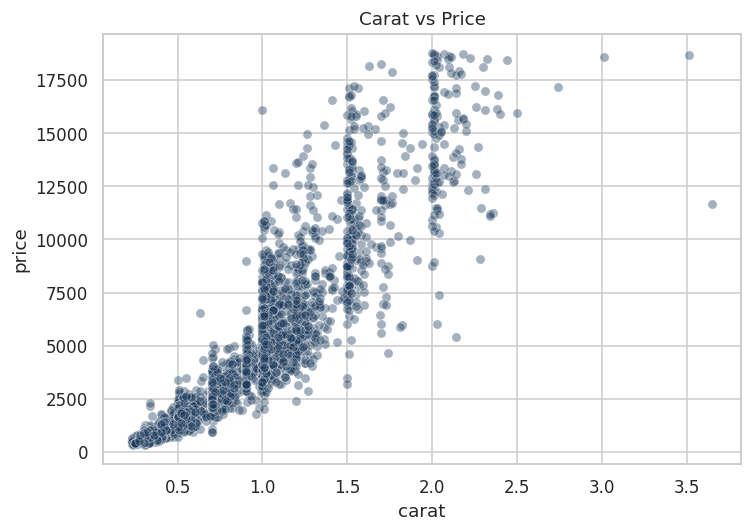

In [4]:
carat_price_corr = df["carat"].corr(df["price"])
print(f"Correlation between carat and price: {carat_price_corr:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
sample = df.sample(4000, random_state=42)
sns.scatterplot(data=sample, x="carat", y="price", alpha=0.4, color="#1B3A5C", ax=ax)
ax.set_title("Carat vs Price")
plt.tight_layout()
plt.savefig("charts/02_carat_vs_price.png")
plt.show()

**Finding:** carat correlates with price at 0.92, by far the strongest relationship in the dataset. Any category-level comparison (cut, color, clarity) has to account for this before it means anything, since categories are not evenly distributed across carat sizes.

## 5. Price by Cut: a Misleading First Look

cut
Fair         4341.95
Good         3919.12
Very Good    3981.02
Premium      4583.50
Ideal        3462.75
Name: price, dtype: float64


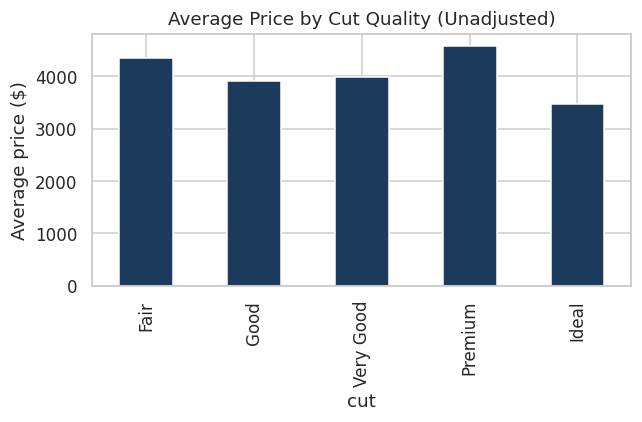

In [5]:
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
avg_price_by_cut = df.groupby("cut", observed=True)["price"].mean().reindex(cut_order)
print(avg_price_by_cut.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
avg_price_by_cut.plot.bar(color="#1B3A5C", ax=ax)
ax.set_ylabel("Average price ($)")
ax.set_title("Average Price by Cut Quality (Unadjusted)")
plt.tight_layout()
plt.savefig("charts/03_avg_price_by_cut_raw.png")
plt.show()

**Finding:** read on its own, this chart says Fair-cut diamonds average \$4,359 while Ideal-cut diamonds average only \$3,458, the best cut looking like the cheapest category. Taken at face value this would be a misleading business conclusion.

## 6. Diagnosing the Confound

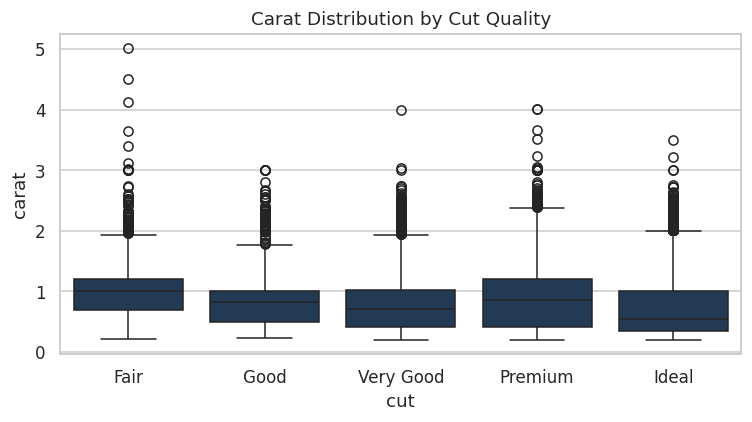

cut
Fair         1.00
Good         0.82
Very Good    0.71
Premium      0.86
Ideal        0.54
Name: carat, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="cut", y="carat", order=cut_order, color="#1B3A5C", ax=ax)
ax.set_title("Carat Distribution by Cut Quality")
plt.tight_layout()
plt.savefig("charts/04_carat_by_cut.png")
plt.show()

print(df.groupby("cut", observed=True)["carat"].median().reindex(cut_order))

**Finding:** Ideal-cut diamonds skew toward smaller carat weights (median 0.31) than Fair-cut diamonds (median 0.70). Cutters take a more conservative, higher-yield-loss approach on already-large stones less often, so the "Ideal" category is disproportionately small stones. Carat, not cut quality, is driving the average price comparison in Section 5.

## 7. Price per Carat: Controlling for Size

cut
Fair         3762.80
Good         3859.36
Very Good    4014.53
Premium      4223.94
Ideal        3922.65
Name: price_per_carat, dtype: float64


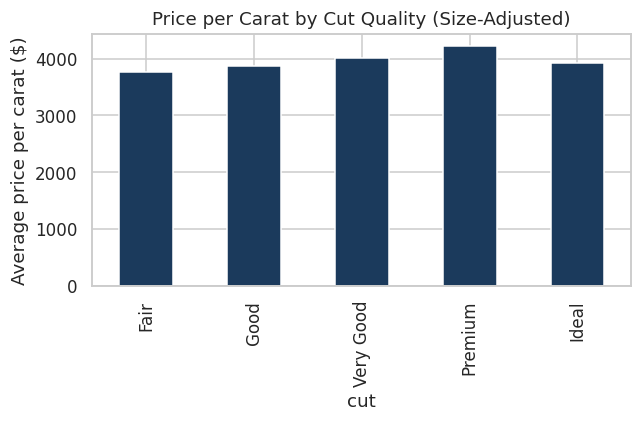

In [7]:
ppc_by_cut = df.groupby("cut", observed=True)["price_per_carat"].mean().reindex(cut_order)
print(ppc_by_cut.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
ppc_by_cut.plot.bar(color="#1B3A5C", ax=ax)
ax.set_ylabel("Average price per carat ($)")
ax.set_title("Price per Carat by Cut Quality (Size-Adjusted)")
plt.tight_layout()
plt.savefig("charts/05_price_per_carat_by_cut.png")
plt.show()

**Finding:** once price is normalized by carat, Fair-cut diamonds drop to the lowest price-per-carat tier (\$3,767) while Premium and Very Good lead (\$4,223 and \$4,014). The size-adjusted view is the one that actually reflects cut quality, and it reverses the naive Section 5 read for the Fair category.

## 8. Price by Clarity and Color

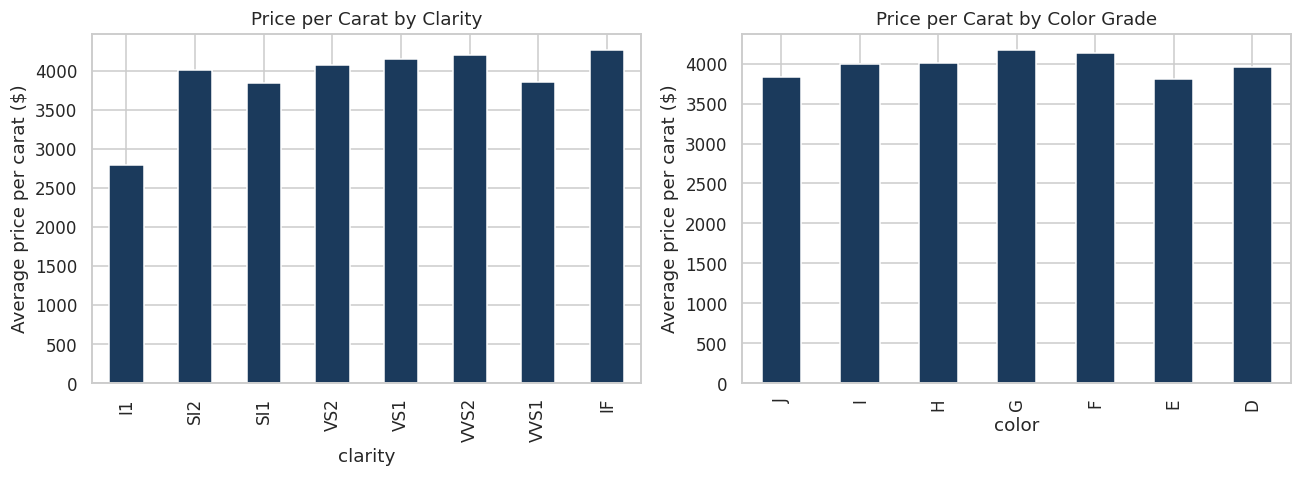

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
df.groupby("clarity", observed=True)["price_per_carat"].mean().reindex(clarity_order).plot.bar(
    color="#1B3A5C", ax=axes[0]
)
axes[0].set_title("Price per Carat by Clarity")
axes[0].set_ylabel("Average price per carat ($)")

color_order = ["J", "I", "H", "G", "F", "E", "D"]
df.groupby("color", observed=True)["price_per_carat"].mean().reindex(color_order).plot.bar(
    color="#1B3A5C", ax=axes[1]
)
axes[1].set_title("Price per Carat by Color Grade")
axes[1].set_ylabel("Average price per carat ($)")

plt.tight_layout()
plt.savefig("charts/06_clarity_color_price_per_carat.png")
plt.show()

**Finding:** price per carat rises steadily with clarity grade from I1 through IF, and with color grade from J (most tinted) through D (colorless), exactly the direction the grading scales are designed to reflect. Unlike cut, these two attributes show a clean, monotonic relationship with size-adjusted price.

## 9. Correlation Analysis

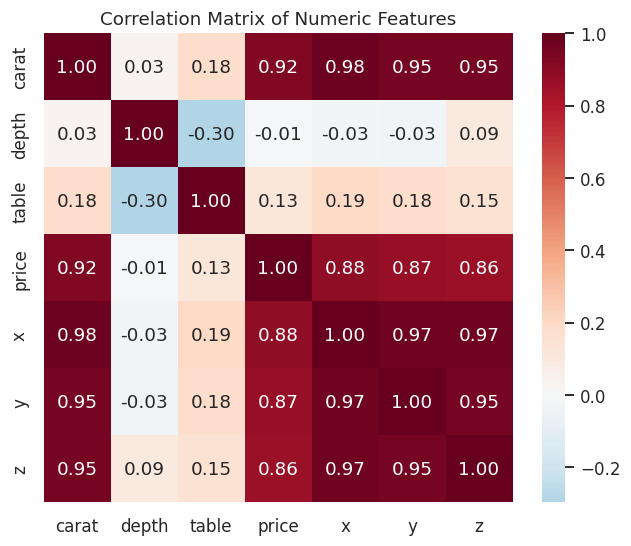

In [9]:
numeric_df = df[["carat", "depth", "table", "price", "x", "y", "z"]]
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.savefig("charts/07_correlation_heatmap.png")
plt.show()

## 10. Summary of Key Insights

- **Carat is the dominant price driver**, correlating with price at 0.92, far ahead of any other single feature.
- **A naive average-price-by-cut comparison is misleading:** Fair-cut diamonds appear to average more (\$4,359) than Ideal-cut diamonds (\$3,458) only because Ideal-cut stones skew toward smaller carats (median 0.31 vs 0.70).
- **Normalizing by carat reverses the picture:** on a price-per-carat basis, Fair drops to the lowest tier (\$3,767) while Premium and Very Good lead (\$4,223 and \$4,014), which is the comparison that actually reflects cut quality.
- **Clarity and color behave as expected:** price per carat rises monotonically from the lowest to the highest grade on both scales, unlike cut.
- **146 duplicate records** were identified and removed during cleaning, out of 53,940 original rows.

**Implication:** the core lesson generalizes past diamonds. Any category-level KPI comparison in a business process (price, cost, cycle time) needs to be checked for a confounding size or volume variable before it is used to draw conclusions, since the unadjusted view can point in the exact opposite direction of the adjusted one.